<a href="https://colab.research.google.com/github/Trieu1020/baitapANN/blob/main/ANN4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from keras.datasets import cifar100
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from keras.utils import to_categorical

path = '/content/drive/MyDrive/mawtj/face_data'

IMG_SIZE = 64
BATCH_SIZE = 16

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

Found 400 images belonging to 5 classes.
Found 100 images belonging to 5 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Flatten(input_shape=(64, 64, 3)),  # chuyển ảnh thành vector 1D

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(train_data.num_classes, activation='softmax')  # đầu ra softmax cho phân loại
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.2012 - loss: 2.1650 - val_accuracy: 0.2100 - val_loss: 11.0975
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.2998 - loss: 1.8552 - val_accuracy: 0.2000 - val_loss: 6.7032
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.2396 - loss: 1.9217 - val_accuracy: 0.2200 - val_loss: 3.1511
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.2681 - loss: 1.7860 - val_accuracy: 0.2000 - val_loss: 3.7287
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.2417 - loss: 1.8135 - val_accuracy: 0.2000 - val_loss: 3.2229
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.2818 - loss: 1.7170 - val_accuracy: 0.2000 - val_loss: 2.2032
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3110 - loss: 1.6702 - val_accuracy: 0.2500 - val_loss: 1.7929
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.3323 - loss: 1.6615 - val_accuracy: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
Loại 2


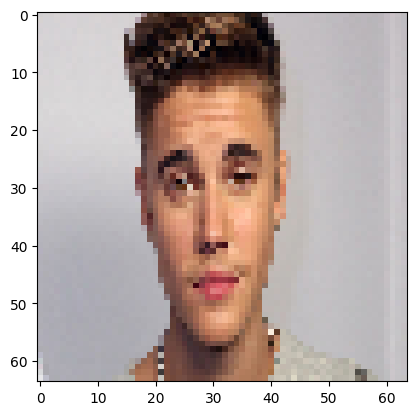

In [ ]:
from keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np

url = '/content/R.jpg'
img=load_img(url,target_size=(64,64))
plt.imshow(img)
img_array=img_to_array(img)/255
img_flatten=img_array.reshape(1,64,64,3)
prediction=model.predict(img_flatten)
print('Loại',np.argmax(prediction))